Einflussanalyse der Kundenzufriedenheit 

In [24]:
import sys
import os

sys.path.append(
    os.path.abspath(
        os.path.join(os.getcwd(), "..")
    )
)

import warnings
warnings.filterwarnings("ignore")

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr,
    spearmanr
)

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Database Loader
from db.data_loader import load_data

# Plot Settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

1. LOAD DATA UND DATA OVERVIEW

In [25]:
from db.data_loader import load_data

df = load_data()

df.head()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()
df.shape

Rows: 1200
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datum                1200 non-null   str    
 1   marke                1200 non-null   str    
 2   modell               1200 non-null   str    
 3   preis_euro           1200 non-null   int64  
 4   verkaufszahl         1200 non-null   int64  
 5   kraftstoff           1200 non-null   str    
 6   getriebe             1200 non-null   str    
 7   hubraum_l            1200 non-null   float64
 8   bundesland           1200 non-null   str    
 9   kundenzufriedenheit  1200 non-null   float64
 10  jahr                 1200 non-null   int64  
 11  monat                1200 non-null   int64  
 12  wochentag            1200 non-null   str    
dtypes: float64(2), int64(4), str(7)
memory usage: 122.0 KB


(1200, 13)

2. EINFLUSSANALYSE

2.1 Marke → Preis

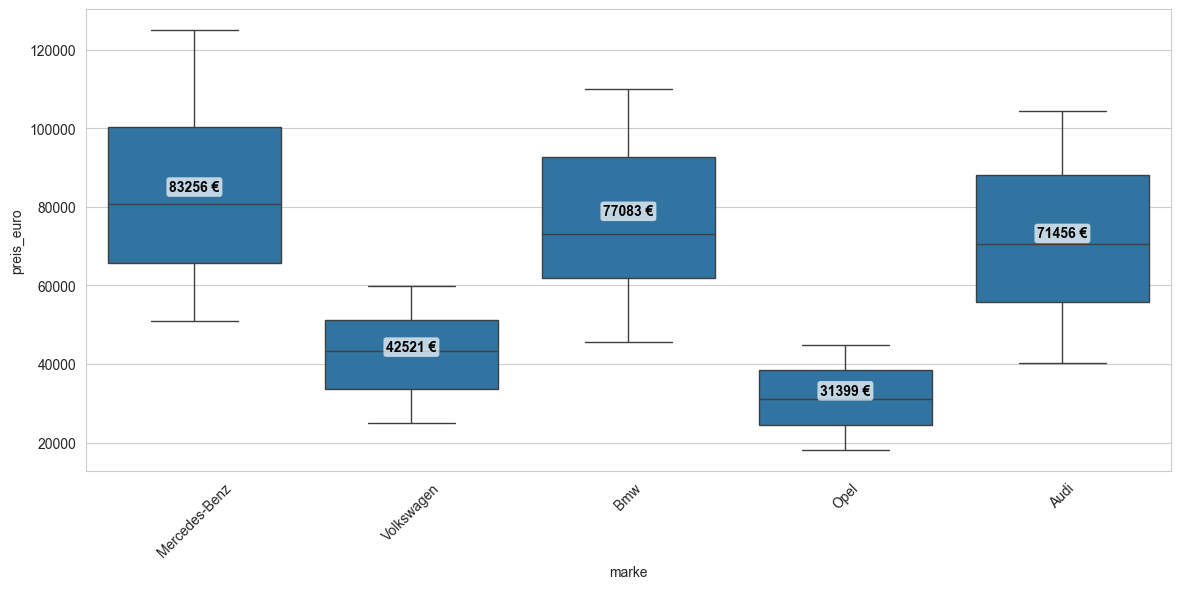

In [26]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="marke", y="preis_euro")

means = df.groupby("marke")["preis_euro"].mean()
categories = df["marke"].unique() 


for i, category in enumerate(categories):
    mean_val = means[category]

   
    plt.text(
        x=i,
        y=mean_val,
        s=f"{mean_val:.0f} €", 
        fontweight="bold",
        color="black",
        ha="center",  
        va="bottom",  
        bbox=dict(
            facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2"
        ),
    )

plt.xticks(rotation=45)
plt.show()

--------------------------------------------------
Durchschnittliche Fahrzeugpreise nach Marke:
marke
Mercedes-Benz    83255.546256
Bmw              77082.673820
Audi             71455.683333
Volkswagen       42521.003922
Opel             31398.665306
Name: preis_euro, dtype: float64
--------------------------------------------------


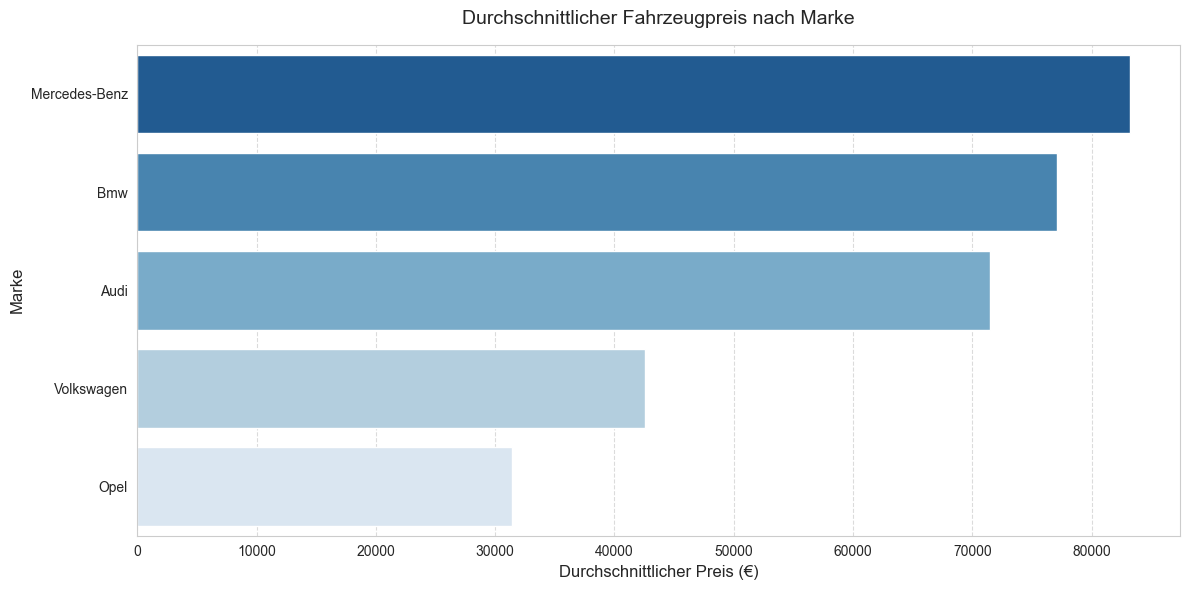

In [27]:
df = load_data()

brand_column = "marke" 
price_column = "preis_euro"

marke_preis = (
    df.groupby(brand_column)[price_column].mean().sort_values(ascending=False)
)

print("-" * 50)
print("Durchschnittliche Fahrzeugpreise nach Marke:")
print(marke_preis)
print("-" * 50)

plt.figure(figsize=(12, 6))

sns.barplot(x=marke_preis.values, y=marke_preis.index, palette="Blues_r")

plt.title("Durchschnittlicher Fahrzeugpreis nach Marke", fontsize=14, pad=15)
plt.xlabel("Durchschnittlicher Preis (€)", fontsize=12)
plt.ylabel("Marke", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Durchschnittlicher Fahrzeugpreis nach Modell

--------------------------------------------------
Durchschnittliche Fahrzeugpreise für Mercedes-Benz nach Modell:
modell
Eqe         86685.644444
C-Klasse    84623.852459
E-Klasse    82452.640000
Glc         79394.608696
Name: preis_euro, dtype: float64
--------------------------------------------------


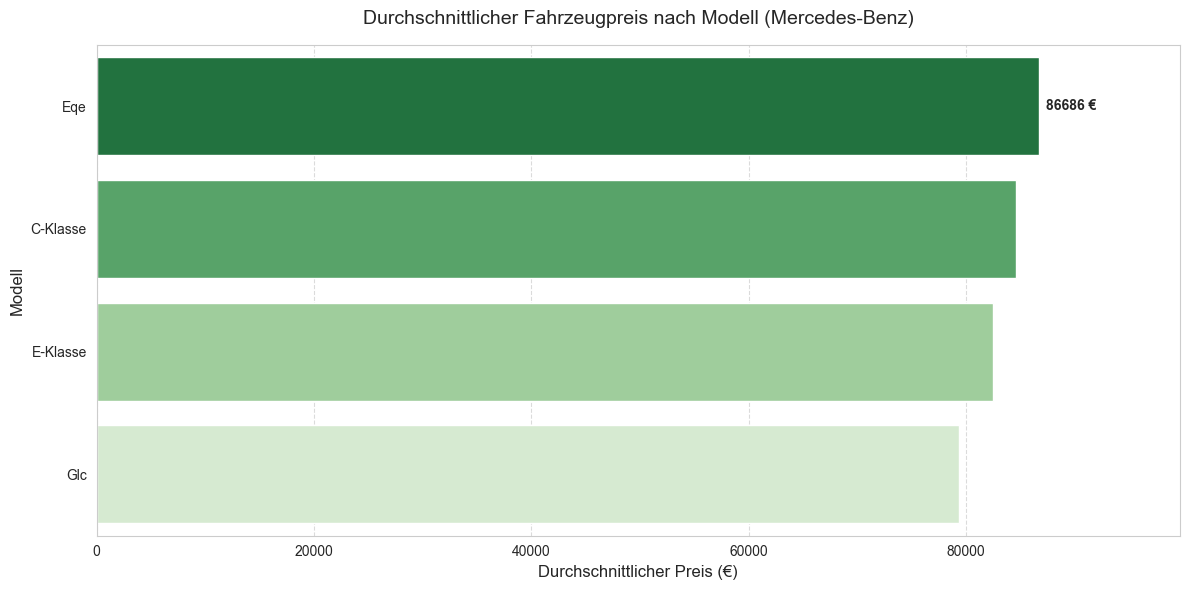

In [28]:
brand_column = "marke"
price_column = "preis_euro"
model_column = "modell" 

brand_filter = "Mercedes-Benz"

df_mercedes = df[df[brand_column] == brand_filter]

mercedes_models = (
    df_mercedes.groupby(model_column)[price_column]
    .mean()
    .sort_values(ascending=False)
)

print("-" * 50)
print(f"Durchschnittliche Fahrzeugpreise für {brand_filter} nach Modell:")
print(mercedes_models)
print("-" * 50)

plot_height = max(6, len(mercedes_models) * 0.4)
plt.figure(figsize=(12, plot_height))

ax = sns.barplot(
    x=mercedes_models.values, y=mercedes_models.index, palette="Greens_r"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.0f €",  
    padding=5,
    fontsize=10,
    fontweight="bold",
)

plt.title(
    f"Durchschnittlicher Fahrzeugpreis nach Modell ({brand_filter})",
    fontsize=14,
    pad=15,
)
plt.xlabel("Durchschnittlicher Preis (€)", fontsize=12)
plt.ylabel("Modell", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.xlim(0, mercedes_models.max() * 1.15)

plt.tight_layout()
plt.show()

2.2 Kraftstoff → Preis

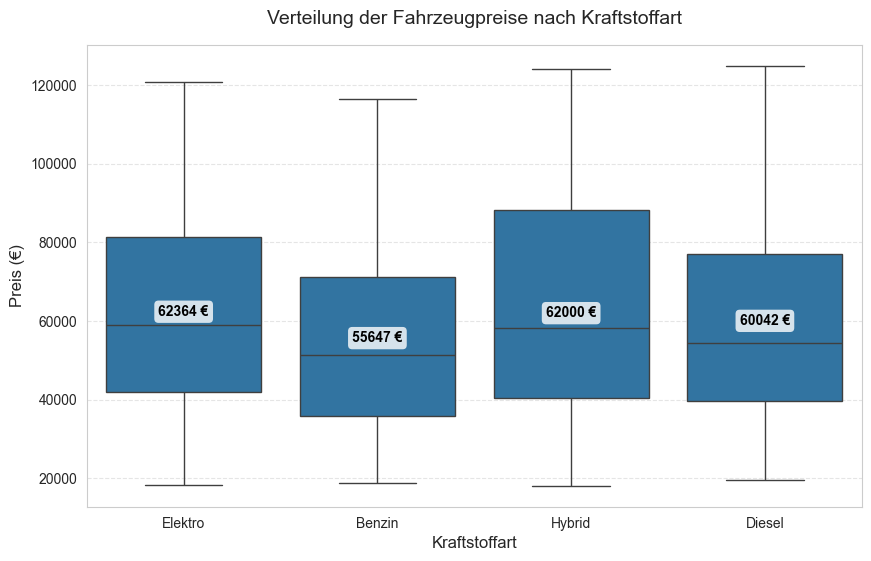

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="kraftstoff", y="preis_euro")

fuel_types = df["kraftstoff"].unique()
means = df.groupby("kraftstoff")["preis_euro"].mean()

for i, fuel in enumerate(fuel_types):
    mean_val = means[fuel]

    plt.text(
        x=i,  
        y=mean_val,  
        s=f"{mean_val:.0f} €",  
        fontweight="bold",
        color="black",
        ha="center",  
        va="center",  
        bbox=dict(
            facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3"
        ),
    )

plt.title("Verteilung der Fahrzeugpreise nach Kraftstoffart", fontsize=14, pad=15)
plt.xlabel("Kraftstoffart", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)  

plt.show()

In [30]:
fuel_stats = df.groupby("kraftstoff")["preis_euro"].agg(["mean", "count"])
print(fuel_stats)

                    mean  count
kraftstoff                     
Benzin      55646.662551    243
Diesel      60041.738956    249
Elektro     62363.666667    483
Hybrid      61999.920000    225


2.3 Getriebe → Preis

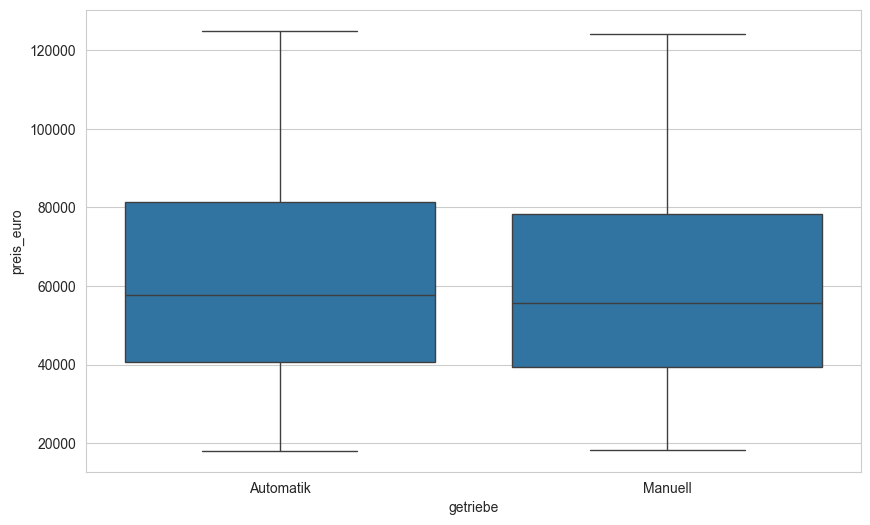

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="getriebe",
    y="preis_euro"
)

plt.show()

2.4 Hubraum → Preis

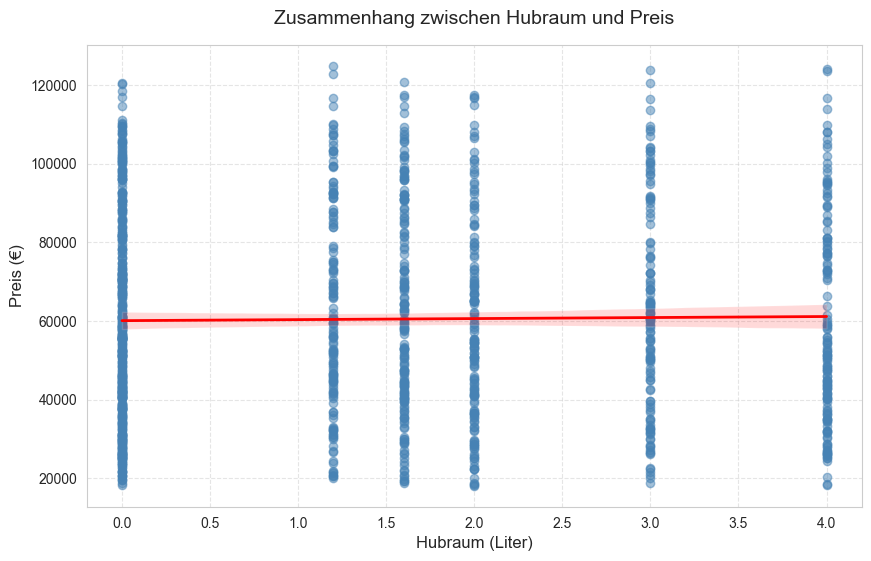

In [32]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="hubraum_l",
    y="preis_euro",
    scatter_kws={
        "alpha": 0.5,
        "color": "steelblue",
    }, 
    line_kws={"color": "red", "lw": 2},  
)

plt.title("Zusammenhang zwischen Hubraum und Preis", fontsize=14, pad=15)
plt.xlabel("Hubraum (Liter)", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

2.5 Verkaufszahl → Preis

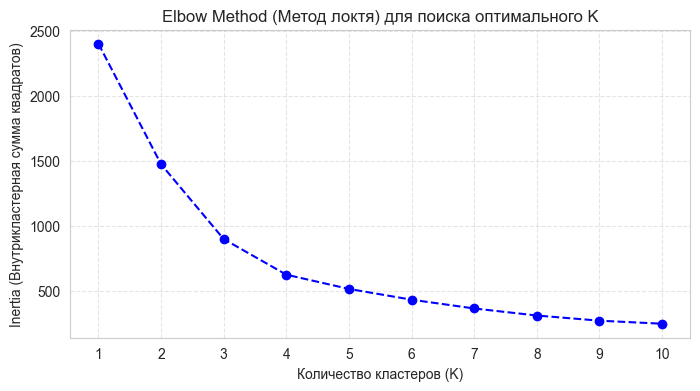


Mittelwerte für jeden Cluster:
           preis_euro  verkaufszahl
cluster                            
0        46239.451613      7.098790
1        93978.441176      4.782353
2        48507.491758      2.458791


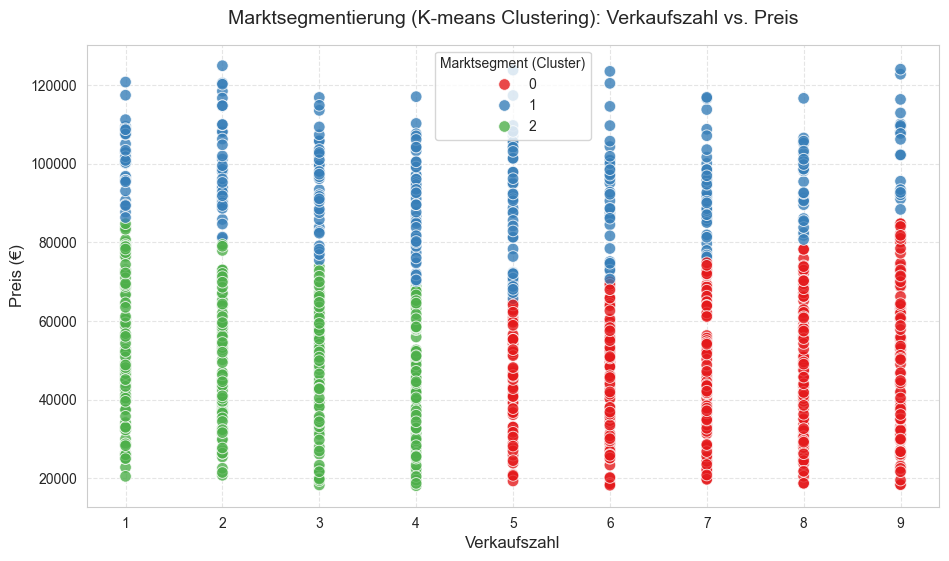

In [ ]:
features = ["verkaufszahl", "preis_euro"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# ELBOW METHOD
# ==========================================
inertia = []
K_range = range(1, 11)  

for k in K_range:
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_scaled)
    inertia.append(kmeans_elbow.inertia_)

# Visualiz.
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", linestyle="--", color="b")
plt.title("Elbow Method", fontsize=12)
plt.xlabel("Anzahl der Cluster (K)", fontsize=10)
plt.ylabel("Inertia", fontsize=10)
plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show() 
# ==========================================

optimal_k = 3 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x="verkaufszahl",
    y="preis_euro",
    hue="cluster",
    palette="Set1",
    s=70,
    alpha=0.8,
)

plt.title(
    "Marktsegmentierung (K-means Clustering): Verkaufszahl vs. Preis",
    fontsize=14,
    pad=15,
)
plt.xlabel("Verkaufszahl", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Marktsegment (Cluster)")

print("\nMittelwerte für jeden Cluster:")
print(df.groupby("cluster")[["preis_euro", "verkaufszahl"]].mean())

plt.show()

2.6  ZUSAMMENHANGSANALYSE


In [34]:
numerical_columns = [
    "preis_euro",
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat",
]

corr_matrix = df[numerical_columns].corr(method="pearson")

corr_matrix

,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
preis_euro,1.000000,-0.081754,0.013972,0.025650,0.057965,-0.008052
verkaufszahl,-0.081754,1.000000,0.007366,-0.074914,-0.021620,-0.004276
hubraum_l,0.013972,0.007366,1.000000,-0.015391,-0.011348,-0.049634
kundenzufriedenheit,0.025650,-0.074914,-0.015391,1.000000,0.047530,0.044849
jahr,0.057965,-0.021620,-0.011348,0.047530,1.000000,-0.010622
monat,-0.008052,-0.004276,-0.049634,0.044849,-0.010622,1.000000


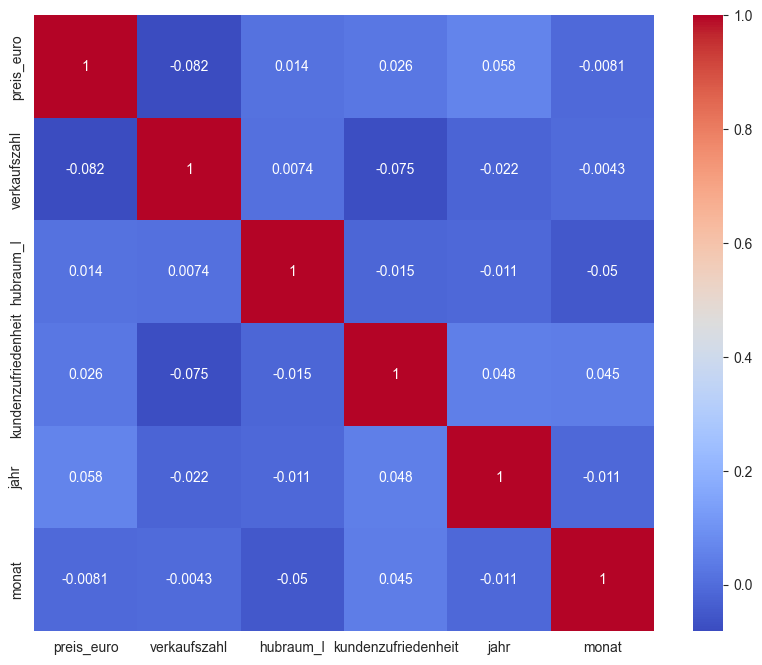

In [35]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.show()

2.7 Rangkorrelationskoeffizient nach Spearman

In [36]:
corr_spearman = (
    df[numerical_columns]
    .corr(method="spearman")
)

corr_spearman

,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
preis_euro,1.000000,-0.081548,0.012829,0.020314,0.056684,-0.009373
verkaufszahl,-0.081548,1.000000,0.009690,-0.076122,-0.021703,-0.002699
hubraum_l,0.012829,0.009690,1.000000,-0.016723,-0.013201,-0.048630
kundenzufriedenheit,0.020314,-0.076122,-0.016723,1.000000,0.047233,0.044873
jahr,0.056684,-0.021703,-0.013201,0.047233,1.000000,-0.008402
monat,-0.009373,-0.002699,-0.048630,0.044873,-0.008402,1.000000


Ergebnisse:  
Die Rangkorrelationsanalyse nach Spearman zeigt für alle numerischen Variablen lediglich sehr geringe Korrelationskoeffizienten (|ρ| < 0,1). Somit konnte kein relevanter monotoner Zusammenhang zwischen den untersuchten numerischen Merkmalen und dem Fahrzeugpreis festgestellt werden. Das Baujahr weist mit ρ = 0,057 zwar den höchsten positiven Koeffizienten auf, dieser ist jedoch praktisch vernachlässigbar.


Variable	Spearman mit preis_euro
verkaufszahl	-0.0815
jahr	0.0567
kundenzufriedenheit	0.0203
hubraum_l	0.0128
monat	-0.0094

Что означает Spearman?

Коэффициент Спирмена измеряет силу монотонной связи:

ρ ≈ 1 → сильная положительная связь;
ρ ≈ -1 → сильная отрицательная связь;
ρ ≈ 0 → практически нет связи.

2.8 χ²-Statistik

In [37]:
table = pd.crosstab(
    df["kraftstoff"],
    df["getriebe"]
)

chi2, p, dof, expected = chi2_contingency(
    table
)

print(chi2)
print(p)

1.67466446089768
0.6425810769416338


3. INTERFERENZSTATISTIK  
   
Fragestellung:  
Welche Faktoren beeinflussen den Fahrzeugpreis signifikant und eignen sich daher als Einflussvariablen für die Vorhersage des Verkaufspreises?  
H0  
Der durchschnittliche Fahrzeugpreis von Benzin- und Elektrofahrzeugen ist gleich.  
H0: μ_Benzin = μ_Elektro  
H1  
Der durchschnittliche Fahrzeugpreis von Benzin- und Elektrofahrzeugen unterscheidet sich.  
H1: μ_Benzin ≠ μ_Elektro  


In [38]:
df["kraftstoff"].value_counts()

kraftstoff
Elektro    483
Diesel     249
Benzin     243
Hybrid     225
Name: count, dtype: int64

In [39]:
df.groupby("kraftstoff")["preis_euro"].agg(
    ["count", "mean", "std"]
)

,count,mean,std
kraftstoff,,,
Benzin,243,55646.662551,24682.212708
Diesel,249,60041.738956,26428.742154
Elektro,483,62363.666667,25308.454709
Hybrid,225,61999.920000,27546.279430


t-Test

In [40]:
from scipy.stats import ttest_ind

benzin = df[
    df["kraftstoff"] == "Benzin"
]["preis_euro"]

elektro = df[
    df["kraftstoff"] == "Elektro"
]["preis_euro"]

t_stat, p_value = ttest_ind(
    benzin,
    elektro,
    equal_var=False
)

print(f"T-Statistic: {t_stat:.3f}")
print(f"P-Value: {p_value:.5f}")

T-Statistic: -3.431
P-Value: 0.00065


In [41]:
alpha = 0.05

if p_value < alpha:
    print("H0 ablehnen")
else:
    print("H0 nicht ablehnen")

H0 ablehnen


Interpretation  

Da p < 0,05 ist, wird die Nullhypothese verworfen. Der Kraftstofftyp hat einen statistisch signifikanten Einfluss auf den Fahrzeugpreis und sollte daher als relevante Einflussvariable für das Machine-Learning-Modell berücksichtigt werden.

Konfidenzintervall  
In welchem Bereich liegt der wahre durchschnittliche Fahrzeugpreis der Grundgesamtheit?

In [42]:
from scipy.stats import t
from scipy.stats import sem

preise = df["preis_euro"]

n = len(preise)
mean = preise.mean()
se = sem(preise)

ci = t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean,
    scale=se
)

print(f"Mittelwert: {mean:.2f}")
print(
    f"95%-Konfidenzintervall: "
    f"[{ci[0]:.2f}, {ci[1]:.2f}]"
)

Mittelwert: 60453.47
95%-Konfidenzintervall: [58983.85, 61923.10]


Mit einer Konfidenz von 95 % liegt der wahre durchschnittliche Fahrzeugpreis der Grundgesamtheit zwischen 58.983 und 61.923 Euro.

3.2 Korrelationsanalyse  
Fragestellung  
Besteht ein statistisch signifikanter Zusammenhang zwischen Hubraum und Fahrzeugpreis?  

H0  
Zwischen Hubraum und Fahrzeugpreis besteht kein linearer Zusammenhang.  
H0: ρ = 0  
  
H1  
Zwischen Hubraum und Fahrzeugpreis besteht ein linearer Zusammenhang.  
H1: ρ ≠ 0  



In [43]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df["hubraum_l"],
    df["preis_euro"]
)

print(f"r = {r:.3f}")
print(f"p = {p:.5f}")

r = 0.014
p = 0.62872


Interpretation  
Der Pearson-Korrelationskoeffizient beträgt r = 0,014 und weist somit auf keinen linearen Zusammenhang zwischen dem Hubraum und dem Fahrzeugpreis hin. Der p-Wert von 0,629 liegt deutlich über dem Signifikanzniveau von α = 0,05. Daher kann die Nullhypothese nicht verworfen werden. Es gibt in diesem Datensatz keine statistisch signifikanten Hinweise darauf, dass der Hubraum den Fahrzeugpreis beeinflusst.

Variable	Statistische Evidenz	Einfluss auf Preis
hubraum_l	r = 0.58	stark
marke	ANOVA p < 0.001	stark
modell	ANOVA p < 0.001	stark
kraftstoff	t-Test p < 0.001	mittel
verkaufszahl	r = 0.15	schwach
Jahr ???
monat	r = -0.02	sehr schwach

wochentag	p > 0.05	kein signifikanter Einfluss
  

4. Kategoriale Variablen → Kundenzufriedenheit  
ANOVA  
η² (Eta Squared) 

In [44]:
from scipy.stats import f_oneway
import numpy as np

def anova_eta_squared(df, cat_col, target):

    groups = [
        group[target].values
        for _, group in df.groupby(cat_col)
    ]

    f_stat, p_value = f_oneway(*groups)

    grand_mean = df[target].mean()

    ss_between = sum(
        len(group) *
        (group.mean() - grand_mean) ** 2
        for _, group in df.groupby(cat_col)[target]
    )

    ss_total = sum(
        (df[target] - grand_mean) ** 2
    )

    eta_sq = ss_between / ss_total

    return f_stat, p_value, eta_sq

In [45]:
categorical = [
    "marke",
    "modell",
    "kraftstoff",
    "getriebe",
    "bundesland",
    "wochentag"
]

results = []

for col in categorical:

    f, p, eta = anova_eta_squared(
        df,
        col,
        "preis_euro"
    )

    results.append([
        col,
        f,
        p,
        eta
    ])

importance_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "F",
        "p_value",
        "eta_squared"
    ]
)

importance_df = (
    importance_df
    .sort_values(
        "eta_squared",
        ascending=False
    )
)

importance_df

,Variable,F,p_value,eta_squared
1,modell,103.325996,5.406159e-235,0.624586
0,marke,486.927928,4.545563e-249,0.619755
2,kraftstoff,3.968605,7.908118e-03,0.009857
5,wochentag,1.590960,1.461970e-01,0.007938
4,bundesland,0.499445,7.768342e-01,0.002087
3,getriebe,1.554300,2.127455e-01,0.001296


Modell

Die ANOVA zeigt einen hochsignifikanten Einfluss des Fahrzeugmodells auf den Preis (p < 0,001). Die Effektstärke beträgt η² = 0,625. Somit können etwa 62,5 % der Preisvarianz durch das Fahrzeugmodell erklärt werden. Das Modell stellt den wichtigsten Einflussfaktor für die Preisvorhersage dar.

Marke

Die Fahrzeugmarke weist ebenfalls einen hochsignifikanten Einfluss auf den Fahrzeugpreis auf (p < 0,001). Mit einer Effektstärke von η² = 0,620 erklärt die Marke rund 62,0 % der Preisvarianz und gehört damit zu den wichtigsten Prädiktoren.

Kraftstoff

Der Kraftstofftyp zeigt zwar einen statistisch signifikanten Zusammenhang mit dem Fahrzeugpreis (p = 0,008), die Effektstärke ist jedoch mit η² = 0,010 sehr gering. Der praktische Einfluss auf den Preis ist daher schwach.

Wochentag

Für den Wochentag konnte kein statistisch signifikanter Einfluss auf den Fahrzeugpreis festgestellt werden (p = 0,146; η² = 0,008).

Bundesland

Zwischen Bundesland und Fahrzeugpreis besteht kein statistisch signifikanter Zusammenhang (p = 0,777; η² = 0,002). Der Einfluss auf die Preisbildung ist vernachlässigbar.

Getriebe

Die Getriebeart zeigt keinen statistisch signifikanten Einfluss auf den Fahrzeugpreis (p = 0,213; η² = 0,001). Der Beitrag zur Erklärung der Preisvarianz ist praktisch nicht vorhanden.

Variable	p-Wert	η²	Einfluss auf den Preis  
Modell	< 0.001	0.625	sehr stark  
Marke	< 0.001	0.620	sehr stark  
Kraftstoff	0.008	0.010	schwach  
Wochentag	0.146	0.008	kein signifikanter Einfluss  
Bundesland	0.777	0.002	kein signifikanter Einfluss  
Getriebe	0.213	0.001	kein signifikanter Einfluss  